# Optimal Portfolio Allocation Using Historical Stock Data

<a href="https://colab.research.google.com/github/bensonmacharia/ML/blob/main/optimal_portfolio_allocation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Goal

Find the portfolio weights that:
- maximize expected return for a given risk level
OR
- minimize risk for a target return

subject to constraints like:
- weights sum to 1
- no short selling (weight >= 0)
- optional max allocation per asset

### Import required packages and download financial data

In [98]:
import yfinance as yf
import pandas as pd
import datetime as dt
import numpy as np

# Define the stock tickers and the date range for historical data
tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA']
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*3)

data = yf.download(tickers, start=startDate, end=endDate, auto_adjust=True)['Close']
print(data.head())

[*********************100%***********************]  7 of 7 completed

Ticker            AAPL        AMZN       GOOGL        META        MSFT  \
Date                                                                     
2023-05-16  169.691071  113.400002  118.530342  236.960480  304.528198   
2023-05-17  170.302490  115.500000  119.849449  240.601868  307.406403   
2023-05-18  172.629868  118.150002  121.823135  244.927933  311.831512   
2023-05-19  172.738342  116.250000  121.753700  243.727386  311.655304   
2023-05-22  171.791626  115.010002  124.024933  246.386505  314.435638   

Ticker           NVDA        TSLA  
Date                               
2023-05-16  29.187164  166.520004  
2023-05-17  30.151310  173.860001  
2023-05-18  31.649982  176.889999  
2023-05-19  31.236347  180.139999  
2023-05-22  31.148426  188.869995  


### Compute Daily Returns

In [99]:
# Calculate daily returns with percentage change and drop the first row which will be NaN
returns = data.pct_change().dropna()
returns.head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2023-05-17,0.003603,0.018519,0.011129,0.015367,0.009451,0.033033,0.044079
2023-05-18,0.013666,0.022944,0.016468,0.017980,0.014395,0.049705,0.017428
2023-05-19,0.000628,-0.016081,-0.000570,-0.004902,-0.000565,-0.013069,0.018373
2023-05-22,-0.005481,-0.010667,0.018654,0.010910,0.008921,-0.002815,0.048462
2023-05-23,-0.015155,-0.000174,-0.019912,-0.006363,-0.018432,-0.015653,-0.016413


### Compute Expected Returns and Covariance Matrix

In [100]:
# Expected annual returns
mean_returns = returns.mean() * 252

# Annualized covariance matrix
cov_matrix = returns.cov() * 252

mean_returns, cov_matrix

(Ticker
 AAPL     0.227249
 AMZN     0.330114
 GOOGL    0.449171
 META     0.385262
 MSFT     0.140605
 NVDA     0.809275
 TSLA     0.481774
 dtype: float64,
 Ticker      AAPL      AMZN     GOOGL      META      MSFT      NVDA      TSLA
 Ticker                                                                      
 AAPL    0.066627  0.034791  0.032369  0.034925  0.025674  0.044065  0.062359
 AMZN    0.034791  0.096264  0.049274  0.067396  0.039691  0.068994  0.073108
 GOOGL   0.032369  0.049274  0.087612  0.044832  0.027436  0.056402  0.066793
 META    0.034925  0.067396  0.044832  0.129518  0.044673  0.082864  0.071090
 MSFT    0.025674  0.039691  0.027436  0.044673  0.055974  0.058505  0.049725
 NVDA    0.044065  0.068994  0.056402  0.082864  0.058505  0.239618  0.104485
 TSLA    0.062359  0.073108  0.066793  0.071090  0.049725  0.104485  0.335222)

### Define Portfolio Functions

**Portfolio return**. Calculates the expected return of a portfolio.

$$
R_p = \sum_{i=1}^{n} w_i R_i
$$

Meaning of the symbols
- $R_p $ = total portfolio return
- $n $ = number of assets in the portfolio
- $w_i $ = weight of asset i in the portfolio
- $R_i $ = return of asset i

The formula multiplies the proportion invested in each asset ($w_i $) by that asset’s return ($R_i $) and then adds all the contributions together.


**Portfolio variance**. This formula measures the risk (variance) of a portfolio.

$$
\sigma_p^2 = w^T \Sigma w
$$

This formula measures the risk (variance) of a portfolio.
- $\sigma_p^2 $ = portfolio variance
- $w $ = vector of portfolio weights
- $w^T $ = transpose of the weight vector
- $\Sigma $ = covariance matrix of asset returns

In [101]:
# Function to calculate portfolio return for given weights
def portfolio_return(weights):
    return np.sum(mean_returns * weights)

# Function to calculate portfolio volatility for given weights
def portfolio_volatility(weights):
    return np.sqrt(
        np.dot(weights.T,
               np.dot(cov_matrix, weights))
    )

### Optimization Problem

Formulate an objective function to minimize portfolio volatility:

In [102]:
def objective(weights):
    return portfolio_volatility(weights)

### Constraints

Weights must sum to 1:

$$
\sum_{i=1}^{n} w_i = 1
$$

This is a portfolio weight constraint used in portfolio optimisation.
- $w_i $ represents the weight allocated to asset i
- The weights must add up to 1 (or 100%)

In [103]:
# Constraints: weights must sum to 1
constraints = ({
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
})

# No short selling: weights must be between 0 and 1
bounds = tuple((0, 1) for asset in range(len(tickers)))

### Run Optimization

In [104]:
from scipy.optimize import minimize

num_assets = len(tickers)

# Start with equal weights as the initial guess
initial_weights = num_assets * [1. / num_assets]

# Perform the optimization to find the optimal weights that minimize portfolio volatility
result = minimize(
    objective,
    initial_weights,
    method='SLSQP', # Sequential Least Squares Programming
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

### Visualize the Optimal Portfolio

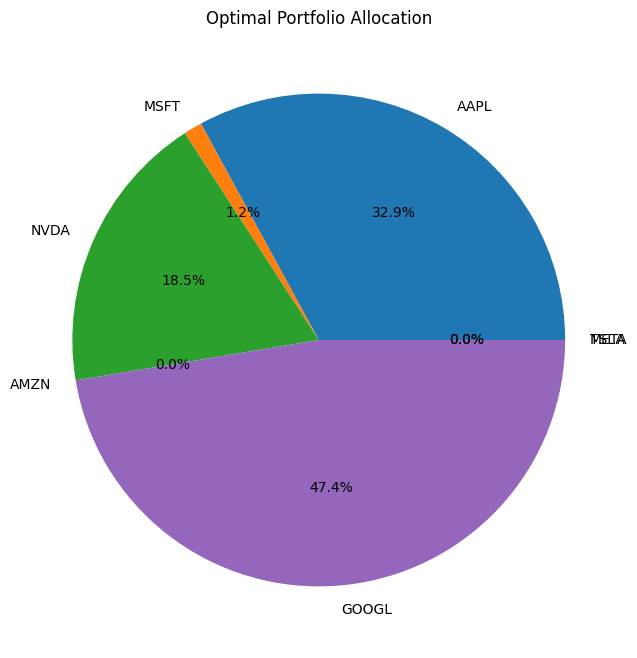

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

# Create a pie chart to visualize the optimal portfolio allocation
plt.pie(
    optimal_weights,
    labels=tickers,
    autopct='%1.1f%%' # Show percentage allocation
)

plt.title('Optimal Portfolio Allocation')
plt.show()